In [33]:
import pandas as pd
import numpy as np
import networkx as nx
import pickle
import matplotlib.pyplot as plt

from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

In [4]:
main_df = pd.read_csv(f"small_data/main_df.csv")

In [5]:
main_df

,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,objNuclei_Location_Center_X,objNuclei_Location_Center_Y
0,1,1,1,0,303.000,0.704407,1.33383,932.211,875.248
1,1,1,1,1,333.000,0.848242,1.33791,932.150,874.174
2,1,1,1,2,314.000,1.059170,1.37627,932.376,873.787
3,1,1,1,3,322.000,1.188000,1.35754,932.168,873.453
4,1,1,1,4,313.999,1.205540,1.36695,931.146,872.885
...,...,...,...,...,...,...,...,...,...
356627,1,1,2857,253,165.000,0.597341,1.32403,1019.050,771.624
356628,1,1,2857,254,192.000,0.587024,1.28853,1019.060,773.099
356629,1,1,2857,255,200.000,0.587822,1.28325,1019.100,773.540
356630,1,1,2857,256,192.000,0.579069,1.29542,1018.930,772.469


In [6]:
sorted_main_df = main_df.set_index(['Image_Metadata_T', 'track_id']).sort_index()
sorted_main_df

Exp_ID  ...  objNuclei_Location_Center_Y
Image_Metadata_T track_id          ...                             
0                1              1  ...                     875.2480
                 2              1  ...                     365.4140
                 3              1  ...                     846.5760
                 4              1  ...                     827.8650
                 5              1  ...                      59.4675
...                           ...  ...                          ...
257              2849           1  ...                     877.9760
                 2850           1  ...                      50.1159
                 2855           1  ...                     205.4320
                 2856           1  ...                     809.4530
                 2857           1  ...                     771.6110

[356632 rows x 7 columns]

In [7]:
def read_graph(path: str) -> nx.Graph:
    with open(path, "rb") as file:
        loaded_data = pickle.load(file)

    return loaded_data

In [8]:
graph0: nx.Graph = read_graph(f"big_data/E1S1/graph_pickles/t_{0}.pkl")
graph1: nx.Graph = read_graph(f"big_data/E1S1/graph_pickles/t_{1}.pkl")

In [9]:
graph0.nodes[0]

{'cell_id': np.int64(1),
 'cell_size': np.float64(303.0),
 'ERKKTR_ratio': np.float64(0.704407),
 'FoxO3A_ratio': np.float64(1.33383),
 'cell_pos': array([932.211, 875.248])}

In [10]:
def calculate_nodes_projections(g0: nx.Graph, g1: nx.Graph) -> dict[int, list[int]]:
    nodes_idx_to_ids_g0: dict[int, int] = nx.get_node_attributes(g0, "cell_id")
    nodes_idx_to_ids_g1: dict[int, int] = nx.get_node_attributes(g1, "cell_id")

    nodes_to_neigbours_in_future: dict[int, list[int]] = {}

    for node in g0.nodes:
        mapping_list: list[int] = []

        if nodes_idx_to_ids_g0[node] in nodes_idx_to_ids_g1.values():
            mapping_list.append(nodes_idx_to_ids_g0[node])

        for neigh in g0.neighbors(node):
            if nodes_idx_to_ids_g0[neigh] in nodes_idx_to_ids_g1.values():
                mapping_list.append(nodes_idx_to_ids_g0[neigh])

        nodes_to_neigbours_in_future[nodes_idx_to_ids_g0[node]] = mapping_list

    return nodes_to_neigbours_in_future

In [11]:
nodes_projections_t0_t1 = calculate_nodes_projections(graph0, graph1)
nodes_projections_t0_t1

{np.int64(1201): [np.int64(1201),
  np.int64(1495),
  np.int64(874),
  np.int64(304)],
 np.int64(1495): [np.int64(1495),
  np.int64(1201),
  np.int64(304),
  np.int64(199),
  np.int64(1165)],
 np.int64(874): [np.int64(874),
  np.int64(1201),
  np.int64(304),
  np.int64(1585),
  np.int64(519),
  np.int64(190)],
 np.int64(304): [np.int64(304),
  np.int64(1201),
  np.int64(692),
  np.int64(1495),
  np.int64(874),
  np.int64(519),
  np.int64(199)],
 np.int64(211): [np.int64(211),
  np.int64(817),
  np.int64(229),
  np.int64(180),
  np.int64(1162)],
 np.int64(817): [np.int64(817),
  np.int64(211),
  np.int64(188),
  np.int64(229),
  np.int64(180),
  np.int64(1428),
  np.int64(832),
  np.int64(703),
  np.int64(801)],
 np.int64(229): [np.int64(229),
  np.int64(211),
  np.int64(1098),
  np.int64(188),
  np.int64(817),
  np.int64(1162),
  np.int64(815)],
 np.int64(180): [np.int64(180),
  np.int64(211),
  np.int64(817),
  np.int64(832),
  np.int64(1162),
  np.int64(926),
  np.int64(904)],
 np.in

In [12]:
def calculate_vector_stats(
        g0: nx.Graph, 
        g1: nx.Graph, 
        tracked_stats_names: list[str] = ['cell_size', 'ERKKTR_ratio', 'FoxO3A_ratio']
    ) -> dict[int, np.ndarray]:
    nodes_projections_t0_t1: dict[int, list[int]] = calculate_nodes_projections(g0, g1)

    ids_to_idx_g0: dict[int, int] = {val: key for key, val in nx.get_node_attributes(g0, "cell_id").items()}
    ids_to_idx_g1: dict[int, int] = {val: key for key, val in nx.get_node_attributes(g1, "cell_id").items()}

    
    subgraph_stats: dict[int, np.ndarray] = {}

    for node_id in nodes_projections_t0_t1:
        stats_vector: list[float] = []

        starting_idx: float = 0
        if node_id == nodes_projections_t0_t1[node_id][0]:
            starting_idx = 1

        stats_vector.append(starting_idx)

        for stat_name in tracked_stats_names:
            stats_vector.append(
                g0.nodes[ids_to_idx_g0[node_id]][stat_name]
            )


        stats_dict: dict[str, list[float]] = {stat_name: [] for stat_name in tracked_stats_names}

        for node_neigh_id in nodes_projections_t0_t1[node_id][starting_idx:]:
            for stat_name in tracked_stats_names:
                stats_dict[stat_name].append(
                    g1.nodes[ids_to_idx_g1[node_neigh_id]][stat_name]
                )

        for stat_name in tracked_stats_names:
            stats_vector.append(np.mean(stats_dict[stat_name]).astype(float))
            stats_vector.append(np.std(stats_dict[stat_name], mean=stats_vector[-1]).astype(float))

        stats_vector.append(len(nodes_projections_t0_t1[node_id]) - starting_idx)

        subgraph_stats[node_id] = np.array(stats_vector)
        
    return subgraph_stats

In [13]:
vector_stats = calculate_vector_stats(graph0, graph1)

df_vec_stats = pd.DataFrame(vector_stats).transpose()

df_vec_stats

,0,1,2,3,4,5,6,7,8,9,10
1201,1.0,333.000,1.067420,1.44699,339.333333,59.015661,0.740077,0.059859,1.330717,0.064827,3.0
1495,1.0,257.000,0.789709,1.37906,400.749500,121.970313,0.747548,0.164359,1.331925,0.057100,4.0
874,1.0,404.000,0.771733,1.41822,294.999600,85.421140,1.009750,0.366792,1.482832,0.162352,5.0
304,1.0,336.999,0.646938,1.23549,342.000000,46.654550,0.954368,0.350935,1.428672,0.114526,6.0
211,1.0,502.000,0.503123,1.08330,321.999500,35.163696,0.781324,0.050461,1.267478,0.089554,4.0
...,...,...,...,...,...,...,...,...,...,...,...
883,1.0,328.000,1.099850,1.47072,319.428571,35.875882,0.881278,0.176257,1.294677,0.132918,7.0
787,1.0,327.001,0.714632,1.29256,327.499667,30.373497,0.751896,0.179528,1.271302,0.139631,6.0
2,1.0,268.001,1.227760,1.20592,391.571286,69.035537,0.911929,0.369445,1.302593,0.102663,7.0
944,1.0,421.999,0.535725,1.31322,363.400200,40.509809,1.183990,0.244397,1.296576,0.117950,5.0


In [21]:
normalized_data = StandardScaler().fit_transform(df_vec_stats)

normalized_data

array([[ 0.07556591,  0.12407198,  0.96866952, ...,  0.47442875,
        -1.03965201, -2.64406366],
       [ 0.07556591, -0.74316852, -0.14723023, ...,  0.49043818,
        -1.14781601, -1.69826887],
       [ 0.07556591,  0.93425717, -0.21946148, ...,  2.48983258,
         0.325461  , -0.75247407],
       ...,
       [ 0.07556591, -0.61763546,  1.61294853, ...,  0.10181126,
        -0.51003682,  1.13911552],
       [ 0.07556591,  1.13964483, -1.16779002, ...,  0.02209282,
        -0.29606078, -0.75247407],
       [ 0.07556591,  0.54628116, -0.28654139, ...,  0.83268665,
        -0.88878854,  0.19332072]], shape=(1409, 11))

In [29]:
labels = HDBSCAN().fit_predict(normalized_data)

df_vec_stats["label"] = labels

/home/kchadzynski/Pulpit/python/Voronoi_graph_in_time/venv/lib64/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [36]:
df_vec_stats

,0,1,2,3,4,5,6,7,8,9,10,label
1201,1.0,333.000,1.067420,1.44699,339.333333,59.015661,0.740077,0.059859,1.330717,0.064827,3.0,1
1495,1.0,257.000,0.789709,1.37906,400.749500,121.970313,0.747548,0.164359,1.331925,0.057100,4.0,1
874,1.0,404.000,0.771733,1.41822,294.999600,85.421140,1.009750,0.366792,1.482832,0.162352,5.0,1
304,1.0,336.999,0.646938,1.23549,342.000000,46.654550,0.954368,0.350935,1.428672,0.114526,6.0,1
211,1.0,502.000,0.503123,1.08330,321.999500,35.163696,0.781324,0.050461,1.267478,0.089554,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
883,1.0,328.000,1.099850,1.47072,319.428571,35.875882,0.881278,0.176257,1.294677,0.132918,7.0,1
787,1.0,327.001,0.714632,1.29256,327.499667,30.373497,0.751896,0.179528,1.271302,0.139631,6.0,1
2,1.0,268.001,1.227760,1.20592,391.571286,69.035537,0.911929,0.369445,1.302593,0.102663,7.0,1
944,1.0,421.999,0.535725,1.31322,363.400200,40.509809,1.183990,0.244397,1.296576,0.117950,5.0,1


In [37]:
graph0.nodes

NodeView((np.int32(1200), np.int32(1357), np.int32(873), np.int32(303), np.int32(210), np.int32(816), np.int32(228), np.int32(179), np.int32(1161), np.int32(1243), np.int32(1153), np.int32(1114), np.int32(1083), np.int32(655), np.int32(1064), np.int32(1228), np.int32(1296), np.int32(1186), np.int32(769), np.int32(1340), np.int32(1269), np.int32(1125), np.int32(1316), np.int32(1132), np.int32(341), np.int32(344), np.int32(1097), np.int32(694), np.int32(1030), np.int32(814), np.int32(187), np.int32(702), np.int32(1327), np.int32(109), np.int32(430), np.int32(479), np.int32(275), np.int32(888), np.int32(1188), np.int32(616), np.int32(642), np.int32(113), np.int32(524), np.int32(178), np.int32(1099), np.int32(1104), np.int32(452), np.int32(1368), np.int32(936), np.int32(821), np.int32(978), np.int32(823), np.int32(1190), np.int32(1209), np.int32(912), np.int32(1283), np.int32(393), np.int32(1237), np.int32(1289), np.int32(1154), np.int32(1240), np.int32(1323), np.int32(322), np.int32(124),

In [44]:
def plot_graph_with_labels(g: nx.Graph, labels: np.ndarray) -> None:
    nx.draw(
        g,
        node_size=[np.pi * (value+0.5) ** 2.5 for value in nx.get_node_attributes(g, "ERKKTR_ratio").values()], 
        width = 0.5, 
        with_labels=False, 
        pos=nx.get_node_attributes(g, "cell_pos"), 
        node_color = [f"C{lab}" if lab != -1 else "black" for lab in labels],
    )
    plt.show()

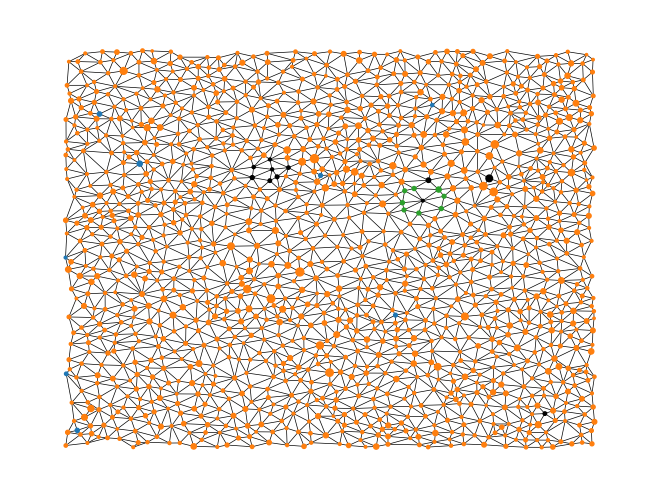

In [45]:
plot_graph_with_labels(graph0, labels)